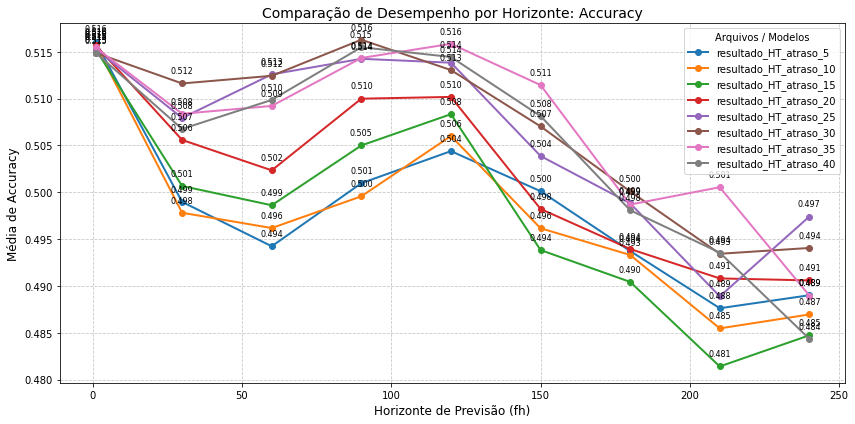

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import os

# ==============================================================================
# LENDO OS ARQUIVOS E PLOTANDO O GRÁFICO
# ==============================================================================

# 1. Configurações
metrica_escolhida = 'Accuracy' # Pode trocar por 'Kappa', 'AUC', 'profit', etc.
modelo = 'HT'  # Nome do modelo para o título do gráfico
categoria = 'nao_fund'  # Categoria a ser filtrada nos dados
atrasos = [5, 10, 15, 20, 25, 30, 35, 40]
plt.figure(figsize=(12, 6))

# 2. Loop para processar cada arquivo
for atraso in atrasos:
    try:
        # Lê o csv
        df = pd.read_csv(f'resultados/resultados_{modelo}_atraso_{atraso}.csv')
        df =  df[df['categoria'] == categoria]  
        arquivo = f'resultado_{modelo}_atraso_{atraso}.csv'
        # Verifica se as colunas necessárias existem
        if 'fh' not in df.columns or metrica_escolhida not in df.columns:
            print(f"Aviso: Arquivo {arquivo} não tem as colunas 'fh' ou '{metrica_escolhida}'. Pulando.")
            continue
            
        # Agrupa por Horizonte (fh) e calcula a média da métrica
        # Isso é importante pois, no seu exemplo, há várias ações (base) para o mesmo fh.
        # Queremos o desempenho médio do modelo naquele horizonte.
        df_agrupado = df.groupby('fh')[metrica_escolhida].mean().sort_index()
        
        # Plota a linha deste arquivo
        # O label será o nome do arquivo (removemos o .csv para ficar bonito)
        nome_legenda = os.path.splitext(os.path.basename(arquivo))[0]
        
        plt.plot(df_agrupado.index, df_agrupado.values, marker='o', linewidth=2, label=nome_legenda)
        
        # Adiciona anotação de valor no gráfico (opcional)
        for x, y in zip(df_agrupado.index, df_agrupado.values):
            plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

    except Exception as e:
        print(f"Erro ao processar o arquivo {arquivo}: {e}")

# 3. Estilização do Gráfico
plt.title(f'Comparação de Desempenho por Horizonte: {metrica_escolhida}', fontsize=14)
plt.xlabel('Horizonte de Previsão (fh)', fontsize=12)
plt.ylabel(f'Média de {metrica_escolhida}', fontsize=12)

# Garante que o eixo X mostre os horizontes corretamente (ex: 1, 30, 60...)
# Se quiser forçar apenas os horizontes que existem nos dados:
# plt.xticks(df_agrupado.index) 

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Arquivos / Modelos")
plt.tight_layout()

# Mostrar o gráfico
plt.show()

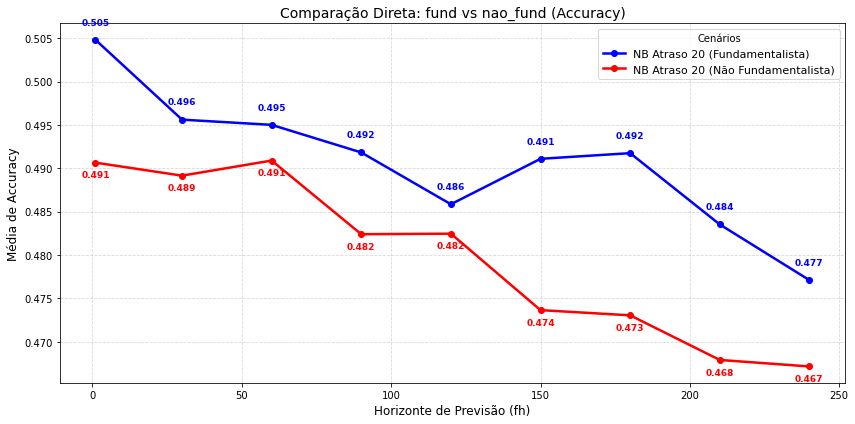

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==============================================================================
# CONFIGURAÇÕES DA COMPARAÇÃO
# ==============================================================================

metrica_escolhida = 'Accuracy' # Ex: 'Kappa', 'AUC', 'profit', 'Accuracy'

# --- Configuração do 1º Caso ---
config_1 = {
    'modelo': 'NB',
    'atraso': 20,            # Defina qual arquivo carregar
    'categoria': 'fund',    # 'fund' ou 'nao_fund'
    'legenda': 'NB Atraso 20 (Fundamentalista)',
    'cor': 'blue'
}

# --- Configuração do 2º Caso ---
config_2 = {
    'modelo': 'NB',         # Pode ser o mesmo modelo ou outro
    'atraso': 20,            # Pode ser o mesmo arquivo ou outro
    'categoria': 'nao_fund',# 'fund' ou 'nao_fund'
    'legenda': 'NB Atraso 20 (Não Fundamentalista)',
    'cor': 'red'
}

# Lista para iterar (facilita se quiser adicionar mais casos no futuro)
casos_para_comparar = [config_1, config_2]

# ==============================================================================
# PROCESSAMENTO E PLOTAGEM
# ==============================================================================

plt.figure(figsize=(12, 6))

for config in casos_para_comparar:
    # Constrói o nome do arquivo baseado no modelo e atraso definidos
    nome_arquivo = f"resultados/resultados_{config['modelo']}_atraso_{config['atraso']}.csv"
    
    try:
        # 1. Leitura
        if not os.path.exists(nome_arquivo):
            print(f"ERRO: O arquivo '{nome_arquivo}' não foi encontrado.")
            continue
            
        df = pd.read_csv(nome_arquivo)
        
        # 2. Verifica colunas
        if 'fh' not in df.columns or metrica_escolhida not in df.columns or 'categoria' not in df.columns:
            print(f"AVISO: Arquivo '{nome_arquivo}' não possui as colunas necessárias. Pulando.")
            continue

        # 3. Filtragem pela Categoria escolhida
        df_filtrado = df[df['categoria'] == config['categoria']].copy()
        
        if df_filtrado.empty:
            print(f"AVISO: Não há dados para a categoria '{config['categoria']}' no arquivo '{nome_arquivo}'.")
            continue

        # 4. Agrupamento (Média por Horizonte)
        df_agrupado = df_filtrado.groupby('fh')[metrica_escolhida].mean().sort_index()
        
        # 5. Plotagem
        plt.plot(df_agrupado.index, 
                 df_agrupado.values, 
                 marker='o', 
                 linewidth=2.5, 
                 label=config['legenda'],
                 color=config.get('cor'))
        
        # Adiciona anotação de valor no gráfico
        for x, y in zip(df_agrupado.index, df_agrupado.values):
            # Pequeno ajuste na posição do texto para não sobrepor (se for o 2º caso, coloca texto para baixo)
            offset = 15 if config == config_1 else -15 
            plt.annotate(f'{y:.3f}', 
                         (x, y), 
                         textcoords="offset points", 
                         xytext=(0, offset), 
                         ha='center', 
                         fontsize=9,
                         fontweight='bold',
                         color=config.get('cor'))

    except Exception as e:
        print(f"Erro inesperado ao processar '{config['legenda']}': {e}")

# ==============================================================================
# ESTILIZAÇÃO FINAL
# ==============================================================================
plt.title(f'Comparação Direta: {config_1["categoria"]} vs {config_2["categoria"]} ({metrica_escolhida})', fontsize=14)
plt.xlabel('Horizonte de Previsão (fh)', fontsize=12)
plt.ylabel(f'Média de {metrica_escolhida}', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Cenários", fontsize=11)

# Ajuste automático das margens
plt.tight_layout()

plt.show()